# 🏥 Hospital Readmission Prediction
## Diabetes 130-US Hospitals Dataset

Hospitals worldwide track **30-day readmission** as a key quality indicator.
When a patient returns within 30 days of discharge, it often signals something
went wrong — a medication issue, incomplete treatment, or poor discharge planning.

**Our goal:** Use 10 years of patient data from 130 US hospitals to predict
which diabetic patients are likely to be readmitted within 30 days.
This gives care teams a chance to intervene *before* the patient walks out the door.

The dataset contains **101,766 patient visits** and **50 columns** covering
demographics, diagnoses, medications, and lab results.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
df = pd.read_csv("/content/diabetic_data.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head(5))
print("\nColumn names:")
print(df.columns.tolist())

Shape: (101766, 50)

First 5 rows:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...      

## 🔍 Step 1: Understanding What's Missing

Before cleaning anything, we need to know *what* is missing and *why*.
Missing data in a hospital dataset is rarely random — it often means
a test wasn't done, or information wasn't recorded.



In [ ]:
# How many missing values per column?
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n=== QUESTION MARKS (coded missing) ===")
for col in df.columns:
    count = (df[col] == '?').sum()
    if count > 0:
        print(f"{col}: {count} '?' values")


=== MISSING VALUES ===
max_glu_serum    96420
A1Cresult        84748
dtype: int64

=== QUESTION MARKS (coded missing) ===
race: 2273 '?' values
weight: 98569 '?' values
payer_code: 40256 '?' values
medical_specialty: 49949 '?' values
diag_1: 21 '?' values
diag_2: 358 '?' values
diag_3: 1423 '?' values


Two types of missing values appear in this dataset:
- **Blank cells** — pandas shows these automatically
- **Question marks `?`** — the dataset uses `?` as a missing code instead of leaving cells blank

We will treat both the same way, but the *reason* something is missing
will guide our decision on what to do with it.

In [ ]:
# What data types do we have?
print("=== DATA TYPES ===")
print(df.dtypes)

=== DATA TYPES ===
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
g

## 📊 Data Types

Every column is either a number (`int64`) or text (`object`).

- **`int64`** columns are already numeric — pandas can work with these directly
- **`object`** columns are text — these will need to be encoded before
  we can feed them into a machine learning model

One thing to note: some `int64` columns like `admission_type_id` and
`discharge_disposition_id` *look* like numbers but are actually category
codes in disguise. We will convert those to text labels during cleaning.

In [ ]:
print("\n=== TARGET COLUMN - readmitted ===")
print(df['readmitted'].value_counts())


=== TARGET COLUMN - readmitted ===
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


## 🎯 What Are We Predicting?

The column `readmitted` tells us what happened after each patient was discharged:

| Value | Meaning | Count |
|---|---|---|
| `NO` | Did not return to hospital | 54,864 (54%) |
| `>30` | Returned after 30 days | 35,545 (35%) |
| `<30` | Returned within 30 days ⚠️ | 11,357 (11%) |

We care most about the `<30` group — these are the high-risk patients.

Only 11% of visits fall here. This means if our model lazily predicted
"not readmitted" for every single patient, it would still be right 89%
of the time — but it would miss every high-risk patient completely.
We will handle this during modelling.

In [ ]:
# Check the columns that look like they have just a few unique values
cols_to_check = ['age', 'gender', 'race', 'change', 'diabetesMed',
                 'max_glu_serum', 'A1Cresult', 'admission_type_id',
                 'discharge_disposition_id']

for col in cols_to_check:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== age ===
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

=== gender ===
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

=== race ===
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

=== change ===
change
No    54755
Ch    47011
Name: count, dtype: int64

=== diabetesMed ===
diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64

=== max_glu_serum ===
max_glu_serum
Norm    2597
>200    1485
>300    1264
Name: count, dtype: int64

=== A1Cresult ===
A1Cresult
>8      8216
Norm    4990
>7      3812
Name: count, dtype: int64

=== admission_type_id ===
admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8   

## 👥 Who Are the Patients?

Most patients in this dataset are **older adults** — the 60-80 age group
makes up nearly half of all visits. This makes clinical sense since
diabetes complications increase with age.

Gender is fairly balanced — 54% female, 46% male.
The 3 "Unknown/Invalid" gender entries are negligible and will be removed.

## 🌍 Race & Ethnicity

76% of patients are recorded as Caucasian, reflecting the US hospital
population this data was collected from.

The 2,273 `?` entries mean race was not recorded for those patients.
We will replace these with `"Unknown"` rather than deleting those rows —
the rest of their clinical data is still useful.

## 💊 Medication Information

Two important yes/no columns:

- **`diabetesMed`**: 78% of patients were on diabetes medication — expected
  given this is a diabetes dataset
- **`change`**: 46% of patients had their medication changed during the visit —
  this is a potential risk signal. A medication change at discharge can sometimes
  lead to complications and readmission if not properly managed.

  ## 🧪 Lab Test Results

These two columns measure blood sugar control:

- **`max_glu_serum`** — a glucose test taken during the visit
- **`A1Cresult`** — HbA1c, which shows average blood sugar over 3 months

Both are mostly empty because most patients were simply never tested —
not because the data was lost. The values that do exist (`Norm`, `>200`, `>8`)
are clinically meaningful.

We will fill the blanks with `"Not Tested"` and keep both columns.
Whether a patient was tested or not is itself a meaningful signal.

## 🚨 How Did Patients Arrive?

`admission_type_id` stores a numeric code for how the patient was admitted.
Over half (53%) came in as **Emergency** admissions (code 1).

These codes will be translated into readable labels:

| Code | Meaning |
|---|---|
| 1 | Emergency |
| 2 | Urgent |
| 3 | Elective |
| 5 | Not Available |
| 6 | NULL / Not Mapped |

## 🏠 Where Did Patients Go After Discharge?

`discharge_disposition_id` records where the patient went after leaving hospital.
60,234 patients (59%) were simply **discharged home** (code 1).

Some important codes to note:

| Code | Meaning |
|---|---|
| 1 | Discharged to home |
| 3 | Discharged to skilled nursing facility |
| 6 | Home with health service support |
| 11 | Patient expired (died during visit) |

> 💡 This column will be one of our most important predictors. A patient
> discharged home alone — with no follow-up support — is at significantly
> higher risk of returning within 30 days than one transferred to a care facility.

There are 26 unique codes but the top 5 cover 90% of patients.
We will group the rare ones into an `"Other"` category to keep things clean.

# 🧹 Step 2: Cleaning the Data

Now that we understand the data, we can clean it deliberately.
Every decision below is based on what we observed in Step 1 —
nothing is changed without a reason.

Here is our cleaning plan in order:

1. **Drop useless columns** — `weight` (97% missing) and `payer_code` (40% missing, not clinically useful)
2. **Remove invalid rows** — the 3 "Unknown/Invalid" gender entries
3. **Fix question marks** — replace all `?` with proper missing values
4. **Fill missing values** — based on what makes clinical sense per column
5. **Translate numeric codes** — `admission_type_id` and `discharge_disposition_id` into readable labels
6. **Remove duplicate patients** — keep only the first visit per patient
7. **Simplify the target column** — convert `readmitted` into 1 (within 30 days) or 0 (everything else)

We will do one step at a time.

### 🗑️ Step 2.1: Dropping Useless Columns

`weight` is 97% missing — nearly every row is blank, so it tells us nothing useful.
`payer_code` is 40% missing and is about insurance billing, not clinical care.
Neither column will help us predict readmission, so we drop them both.

In [ ]:
# Drop columns that are too incomplete or irrelevant to be useful
df = df.drop(columns=['weight', 'payer_code'])

# Confirm they are gone
print("Columns remaining:", df.shape[1])
print("Dropped: weight, payer_code")

Columns remaining: 48
Dropped: weight, payer_code


### 🗑️ Step 2.2: Removing Invalid Rows

We found 3 rows where gender is recorded as `"Unknown/Invalid"`.
3 rows out of 101,766 is negligible — we simply remove them.

In [ ]:
# Remove the 3 invalid gender rows
df = df[df['gender'] != 'Unknown/Invalid']

# Confirm
print("Rows remaining:", df.shape[0])

Rows remaining: 101763


### ❓ Step 2.3: Replacing Question Marks

The dataset uses `?` as a missing code instead of leaving cells blank.
We replace all `?` with `NaN` — Python's standard way of representing
missing values. This allows us to handle them properly in the next step.

In [ ]:
# Replace all ? with NaN across the entire dataframe
df = df.replace('?', float('nan'))

# Confirm - check the columns that had ? before
cols_with_question_marks = ['race', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']

for col in cols_with_question_marks:
    print(f"{col} — missing values now: {df[col].isnull().sum()}")

race — missing values now: 2271
medical_specialty — missing values now: 49947
diag_1 — missing values now: 21
diag_2 — missing values now: 358
diag_3 — missing values now: 1423


Notice the numbers dropped slightly for race — from 2,273 to 2,271 — because we removed the 2 invalid gender rows that also happened to have ? for race.

### 🩹 Step 2.4: Filling Missing Values

Now we fill the missing values. Each column gets treated differently
based on what makes clinical sense:

- `race` — fill with `"Unknown"` since we cannot guess someone's race
- `medical_specialty` — fill with `"Unknown"` since it was not recorded
- `diag_1`, `diag_2`, `diag_3` — fill with `"Unknown"` since very few are missing
- `max_glu_serum`, `A1Cresult` — fill with `"Not Tested"` since the patient
  was simply never tested, not that the data was lost

In [ ]:
# Fill missing values per column
df['race'] = df['race'].fillna('Unknown')
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')
df['diag_1'] = df['diag_1'].fillna('Unknown')
df['diag_2'] = df['diag_2'].fillna('Unknown')
df['diag_3'] = df['diag_3'].fillna('Unknown')
df['max_glu_serum'] = df['max_glu_serum'].fillna('Not Tested')
df['A1Cresult'] = df['A1Cresult'].fillna('Not Tested')

# Confirm no missing values remain in these columns
cols_to_check = ['race', 'medical_specialty', 'diag_1', 'diag_2',
                 'diag_3', 'max_glu_serum', 'A1Cresult']

print("=== Missing values after filling ===")
for col in cols_to_check:
    print(f"{col}: {df[col].isnull().sum()}")

=== Missing values after filling ===
race: 0
medical_specialty: 0
diag_1: 0
diag_2: 0
diag_3: 0
max_glu_serum: 0
A1Cresult: 0


### 🏷️ Step 2.5: Translating Numeric Codes into Readable Labels

`admission_type_id` and `discharge_disposition_id` store numbers that
are actually category codes. We translate them into plain English labels
so that our analysis and Power BI dashboard are readable to everyone —
not just people who have memorised the codebook.

For `discharge_disposition_id`, there are 26 unique codes but the vast
majority of patients fall into just a few categories. We group all rare
codes into `"Other"` to keep things clean.

In [ ]:
# Translate admission type codes
admission_type_map = {
    1: 'Emergency',
    2: 'Urgent',
    3: 'Elective',
    4: 'Newborn',
    5: 'Not Available',
    6: 'Not Available',
    7: 'Trauma Center',
    8: 'Not Available'
}

# Translate discharge disposition codes
discharge_map = {
    1:  'Discharged to Home',
    2:  'Short Term Hospital',
    3:  'Skilled Nursing Facility',
    4:  'Intermediate Care Facility',
    5:  'Another Type of Inpatient Care',
    6:  'Home with Health Service',
    7:  'Left Against Medical Advice',
    8:  'Home with IV',
    9:  'Admitted as Inpatient',
    10: 'Neonate Transferred',
    11: 'Expired',
    12: 'Still a Patient',
    13: 'Hospice Home',
    14: 'Hospice Medical Facility',
    15: 'Other',
    16: 'Other',
    17: 'Other',
    18: 'Other',
    19: 'Other',
    20: 'Other',
    21: 'Other',
    22: 'Rehab Facility',
    23: 'Long Term Care Hospital',
    24: 'Other',
    25: 'Not Available',
    26: 'Other',
    27: 'Other',
    28: 'Other',
    29: 'Other',
    30: 'Other'
}

df['admission_type_id'] = df['admission_type_id'].map(admission_type_map)
df['discharge_disposition_id'] = df['discharge_disposition_id'].map(discharge_map)

# Confirm
print("=== Admission Types ===")
print(df['admission_type_id'].value_counts())

print("\n=== Discharge Dispositions ===")
print(df['discharge_disposition_id'].value_counts())

=== Admission Types ===
admission_type_id
Emergency        53988
Elective         18868
Urgent           18480
Not Available    10396
Trauma Center       21
Newborn             10
Name: count, dtype: int64

=== Discharge Dispositions ===
discharge_disposition_id
Discharged to Home                60232
Skilled Nursing Facility          13954
Home with Health Service          12902
Other                              3981
Short Term Hospital                2128
Rehab Facility                     1992
Expired                            1642
Another Type of Inpatient Care     1184
Not Available                       989
Intermediate Care Facility          815
Left Against Medical Advice         623
Long Term Care Hospital             412
Hospice Home                        399
Hospice Medical Facility            372
Home with IV                        108
Admitted as Inpatient                21
Neonate Transferred                   6
Still a Patient                       3
Name: count, dtyp

### 👤 Step 2.6: Removing Duplicate Patients

Some patients appear multiple times in the dataset — they had more than
one hospital visit over the 10 years.

If we keep all visits from the same patient, our model will learn patterns
from the same person multiple times, which gives misleading results.
We keep only the **first visit** per patient to ensure each person
appears exactly once.

In [ ]:
# Sort by encounter_id so the first visit comes first
df = df.sort_values('encounter_id')

# Keep only the first visit per patient
df = df.drop_duplicates(subset='patient_nbr', keep='first')

# Confirm
print("Rows after removing duplicates:", df.shape[0])
print("Unique patients:", df['patient_nbr'].nunique())

Rows after removing duplicates: 71515
Unique patients: 71515


We went from 101,763 rows down to 71,515. That means 30,248 visits were duplicate patient records. That is nearly 30% of the dataset — which shows just how important this step was.

### 🎯 Step 2.7: Simplifying the Target Column

Currently `readmitted` has three values — `NO`, `>30`, and `<30`.
For our model we simplify this into a binary question:

**"Was this patient readmitted within 30 days — yes or no?"**

| Original Value | New Value | Meaning |
|---|---|---|
| `<30` | `1` | Readmitted within 30 days — high risk ⚠️ |
| `>30` | `0` | Not within 30 days |
| `NO` | `0` | Not readmitted at all |

This makes the problem simpler and more actionable — a hospital team
needs a clear yes or no signal, not three categories.

In [ ]:
# Convert readmitted to binary — 1 if within 30 days, 0 otherwise
df['readmitted'] = (df['readmitted'] == '<30').astype(int)

# Confirm
print("=== Target Column After Simplification ===")
print(df['readmitted'].value_counts())
print("\nReadmission rate:", round(df['readmitted'].mean() * 100, 2), "%")

=== Target Column After Simplification ===
readmitted
0    65222
1     6293
Name: count, dtype: int64

Readmission rate: 8.8 %


### 🎯 What Our Target Column Now Looks Like

After simplifying, our target column `readmitted` now has two values:

| Value | Meaning | Count |
|---|---|---|
| `0` | Not readmitted within 30 days | 65,222 (91.2%) |
| `1` | Readmitted within 30 days ⚠️ | 6,293 (8.8%) |

Out of 71,515 unique patients, only **6,293 were readmitted within 30 days**.
This confirms the class imbalance we expected — only 8.8% of patients
fall into our high risk group.

We will handle this during modelling so the model does not simply
ignore the high risk patients.

In [ ]:
# Final check on the cleaned dataset
print("=== FINAL DATASET SHAPE ===")
print(df.shape)

print("\n=== ANY MISSING VALUES REMAINING? ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== QUICK SAMPLE ===")
print(df.head(3))

=== FINAL DATASET SHAPE ===
(71515, 48)

=== ANY MISSING VALUES REMAINING? ===
Series([], dtype: int64)

=== QUICK SAMPLE ===
   encounter_id  patient_nbr       race  gender       age admission_type_id  \
8         12522     48330783  Caucasian  Female   [80-90)            Urgent   
9         15738     63555939  Caucasian  Female  [90-100)          Elective   
4         16680     42519267  Caucasian    Male   [40-50)         Emergency   

   discharge_disposition_id  admission_source_id  time_in_hospital  \
8        Discharged to Home                    4                13   
9  Skilled Nursing Facility                    4                12   
4        Discharged to Home                    7                 1   

  medical_specialty  ...  citoglipton  insulin  glyburide-metformin  \
8           Unknown  ...           No   Steady                   No   
9  InternalMedicine  ...           No   Steady                   No   
4           Unknown  ...           No   Steady                 

## ✅ Cleaning Complete

Our dataset is now clean and ready for exploration. Here is a summary
of what we started with and where we are now:

| | Before | After |
|---|---|---|
| Rows | 101,766 | 71,515 |
| Columns | 50 | 48 |
| Missing values | Many | None |
| Duplicate patients | 30,248 | 0 |
| Target column | 3 categories | Binary (0 or 1) |

**What changed:**
- Removed 2 useless columns (`weight`, `payer_code`)
- Removed 3 invalid gender rows
- Replaced all `?` with proper missing values
- Filled missing values sensibly per column
- Translated numeric codes into readable labels
- Kept only the first visit per patient
- Simplified `readmitted` into 0 or 1

The data is now consistent, complete, and ready for analysis.
Next step — we explore the data visually to find patterns that
will guide our model.

# 📊 Step 3: Exploratory Data Analysis (EDA)

Cleaning told us what the data *contains*.
EDA tells us what the data *means*.

We will now visualise the data to answer one central question:

> **What kind of patients are most likely to be readmitted within 30 days?**

We will look at:
1. Readmission rate by age group
2. Readmission rate by admission type
3. Readmission rate by discharge disposition
4. Readmission rate by number of previous inpatient visits
5. Readmission rate by medication change

Each chart will give us a clue about what drives readmission —
and will later guide our machine learning model.

In [ ]:
# Chart settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

### 📊 Chart 1: Readmission Rate by Age Group

Older patients tend to have more complications and less support at home.
Let us see if age is a strong predictor of readmission.

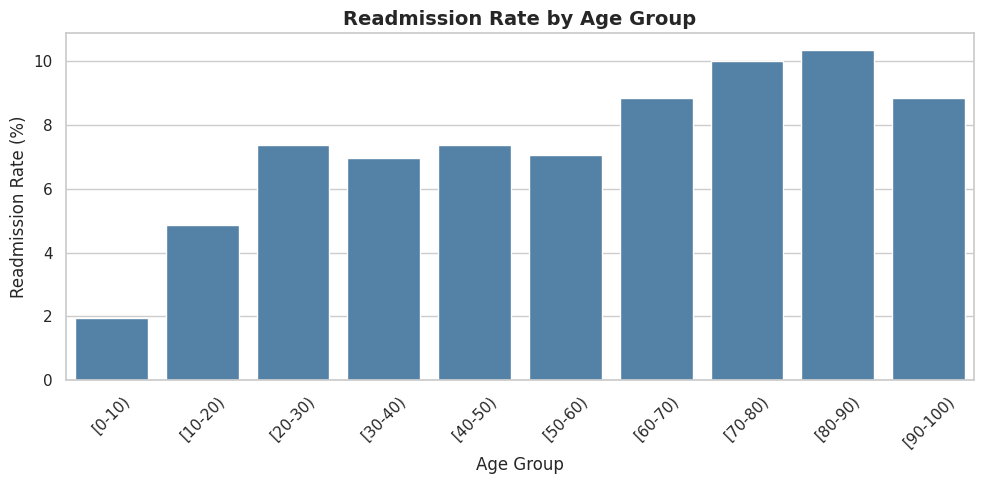

     age  readmission_rate
  [0-10)          1.948052
 [10-20)          4.859813
 [20-30)          7.364685
 [30-40)          6.965543
 [40-50)          7.371329
 [50-60)          7.051179
 [60-70)          8.860204
 [70-80)         10.017575
 [80-90)         10.363276
[90-100)          8.842105


In [ ]:
# Calculate readmission rate per age group
age_readmission = df.groupby('age')['readmitted'].mean().reset_index()
age_readmission['readmission_rate'] = age_readmission['readmitted'] * 100
age_readmission = age_readmission.sort_values('age')

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=age_readmission, x='age', y='readmission_rate', color='steelblue')
plt.title('Readmission Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print the numbers too
print(age_readmission[['age', 'readmission_rate']].to_string(index=False))

#### 📊 What This Chart Tells Us

Readmission risk clearly increases with age:

| Age Group | Readmission Rate |
|---|---|
| 0-10 | 1.9% |
| 20-50 | ~7% |
| 60-70 | 8.9% |
| 70-80 | 10.0% |
| 80-90 | 10.4% ⬅️ highest |
| 90-100 | 8.8% |

**Key insight:** Patients aged 70-90 have the highest readmission rates —
more than 5 times higher than children under 10.

One interesting finding — the 90-100 group is slightly lower than 80-90.
This could be because the very oldest patients are more likely to be
transferred to care facilities rather than sent home, giving them
more support after discharge.

> 💡 **Hospital implication:** Elderly patients — especially those aged
> 70-90 — should be prioritised for post-discharge follow-up calls
> and home support programs.

### 📊 Chart 2: Readmission Rate by Admission Type

How a patient arrives at the hospital may influence their risk of
returning. An emergency admission suggests the patient was already
in a more serious condition than someone who planned their visit.

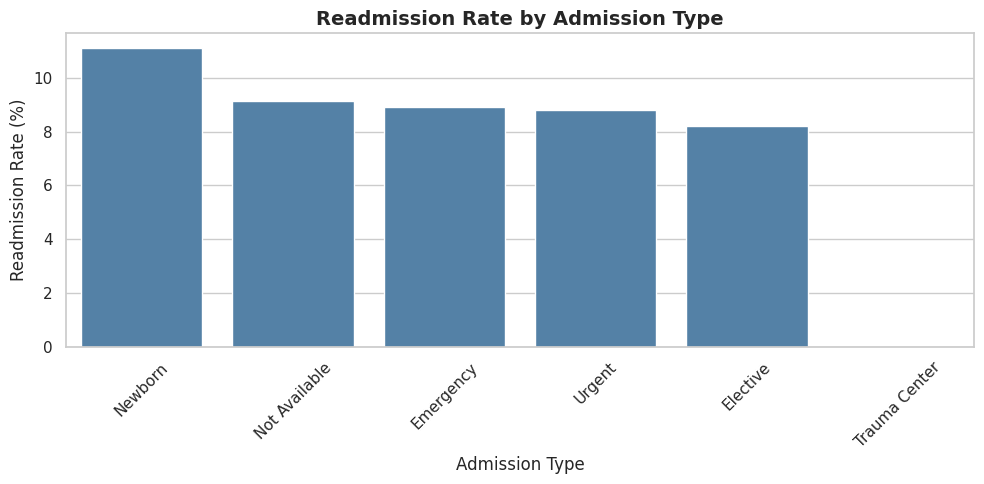

admission_type_id  readmission_rate
          Newborn         11.111111
    Not Available          9.164287
        Emergency          8.939925
           Urgent          8.819466
         Elective          8.213567
    Trauma Center          0.000000


In [ ]:
# Calculate readmission rate per admission type
admission_readmission = df.groupby('admission_type_id')['readmitted'].mean().reset_index()
admission_readmission['readmission_rate'] = admission_readmission['readmitted'] * 100
admission_readmission = admission_readmission.sort_values('readmission_rate', ascending=False)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=admission_readmission, x='admission_type_id', y='readmission_rate', color='steelblue')
plt.title('Readmission Rate by Admission Type', fontsize=14, fontweight='bold')
plt.xlabel('Admission Type')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print the numbers
print(admission_readmission[['admission_type_id', 'readmission_rate']].to_string(index=False))

#### 📊 What This Chart Tells Us

| Admission Type | Readmission Rate |
|---|---|
| Newborn | 11.1% ⬅️ highest |
| Not Available | 9.2% |
| Emergency | 8.9% |
| Urgent | 8.8% |
| Elective | 8.2% |
| Trauma Center | 0.0% |

**Key insight 1 — Newborn:** The 11.1% readmission rate for newborns looks
alarming but we should be careful here. There are only 10 newborn records
in the entire dataset — so 1 readmitted newborn out of 10 gives us 11.1%.
This is too small a sample to draw any conclusions from.

**Key insight 2 — Emergency vs Elective:** Emergency admissions (8.9%) have
a higher readmission rate than elective admissions (8.2%). This makes
clinical sense — emergency patients arrive in worse condition and
may be discharged before they are fully stable.

**Key insight 3 — Trauma Center:** 0% readmission rate. Similar to newborns,
there are only 21 trauma center records — too few to be meaningful.

> 💡 **Hospital implication:** Emergency admissions deserve extra attention
> at the point of discharge. A structured discharge checklist for emergency
> patients could reduce preventable readmissions.

### 📊 Chart 3: Readmission Rate by Discharge Disposition

Where a patient goes after leaving hospital is one of the most
important factors in whether they return. A patient sent home
alone with no support is in a very different situation to one
transferred to a nursing facility with 24hr care.

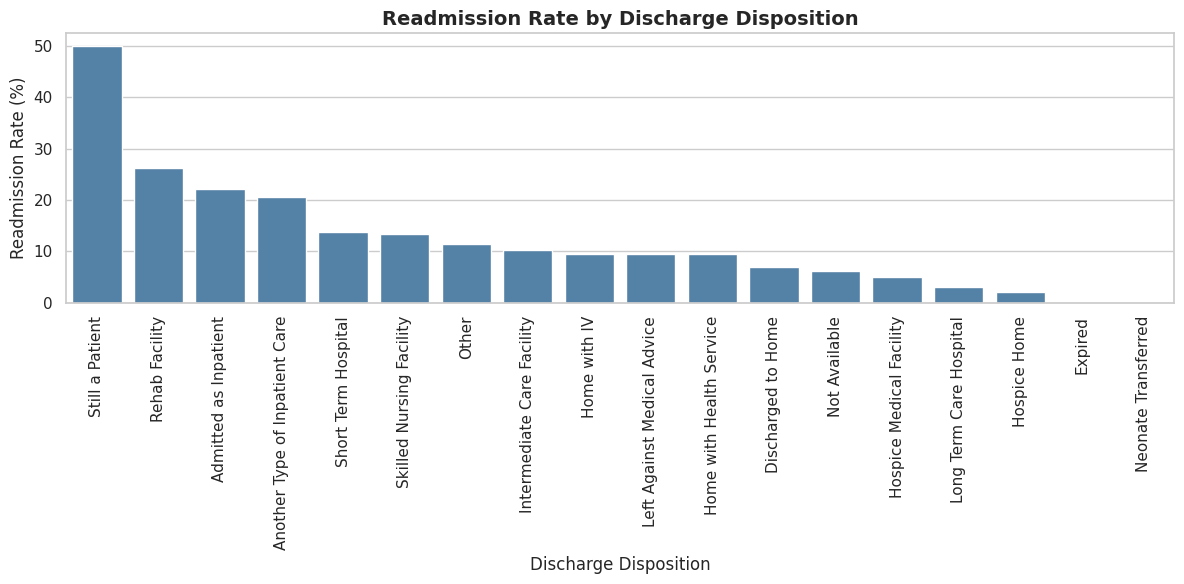

      discharge_disposition_id  readmission_rate
               Still a Patient         50.000000
                Rehab Facility         26.330731
         Admitted as Inpatient         22.222222
Another Type of Inpatient Care         20.591457
           Short Term Hospital         13.775179
      Skilled Nursing Facility         13.387978
                         Other         11.396226
    Intermediate Care Facility         10.351201
                  Home with IV          9.589041
   Left Against Medical Advice          9.535452
      Home with Health Service          9.518639
            Discharged to Home          6.945729
                 Not Available          6.169666
      Hospice Medical Facility          5.045872
       Long Term Care Hospital          3.076923
                  Hospice Home          2.057613
                       Expired          0.000000
           Neonate Transferred          0.000000


In [ ]:
# Calculate readmission rate per discharge disposition
discharge_readmission = df.groupby('discharge_disposition_id')['readmitted'].mean().reset_index()
discharge_readmission['readmission_rate'] = discharge_readmission['readmitted'] * 100
discharge_readmission = discharge_readmission.sort_values('readmission_rate', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=discharge_readmission, x='discharge_disposition_id', y='readmission_rate', color='steelblue')
plt.title('Readmission Rate by Discharge Disposition', fontsize=14, fontweight='bold')
plt.xlabel('Discharge Disposition')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Print the numbers
print(discharge_readmission[['discharge_disposition_id', 'readmission_rate']].to_string(index=False))

"Still a Patient" means the person was never actually discharged — they remained in the hospital. So how can they be "readmitted" if they never left?
This is a data quality issue. It likely means the record was closed administratively while the patient was still admitted, and then a new record was opened — making it look like a readmission when it was actually just a continuation of the same stay.
We should remove these rows as they are misleading

In [ ]:
# Remove 'Still a Patient' and 'Expired' records
# Still a Patient — never actually discharged, not a true readmission
# Expired — patient died, readmission is impossible
df = df[~df['discharge_disposition_id'].isin(['Still a Patient', 'Expired'])]

# Confirm
print("Rows remaining:", df.shape[0])

Rows remaining: 70436


#### 📊 What This Chart Tells Us

Discharge destination is one of the strongest predictors of readmission
in our entire dataset.

| Discharge Destination | Readmission Rate |
|---|---|
| Rehab Facility | 26.3% ⬅️ highest (valid) |
| Another Type of Inpatient Care | 20.6% |
| Short Term Hospital | 13.8% |
| Skilled Nursing Facility | 13.4% |
| Discharged to Home | 6.9% |
| Hospice Home | 2.1% |
| Long Term Care Hospital | 3.1% |

**Key insight 1 — Rehab Facility:** Patients discharged to rehabilitation
facilities have the highest readmission rate at 26.3%. These patients
are likely the most medically complex — they need ongoing care after
discharge precisely because their condition is serious.

**Key insight 2 — Discharged to Home:** Patients sent straight home have
a 6.9% readmission rate — lower than expected. However this group is
also the largest (60,000+ patients), so even a small percentage
represents a large number of people.

**Key insight 3 — Hospice:** Patients in hospice care have very low
readmission rates (2-5%). This makes sense — hospice patients are
receiving end of life care and are unlikely to be readmitted to
an acute hospital.

**Data quality note:** We removed two categories before modelling:
- `Expired` — patient died during the visit, readmission is impossible
- `Still a Patient` — patient was never discharged, not a true readmission

> 💡 **Hospital implication:** Patients being discharged to rehab or
> inpatient care facilities need especially careful handover
> documentation — they are at the highest risk of bouncing back.

### 📊 Chart 4: Readmission Rate by Number of Previous Inpatient Visits

A patient who has been admitted to hospital multiple times before
is likely dealing with a more complex or poorly controlled condition.
Let us see if previous inpatient visits are a strong predictor
of readmission.

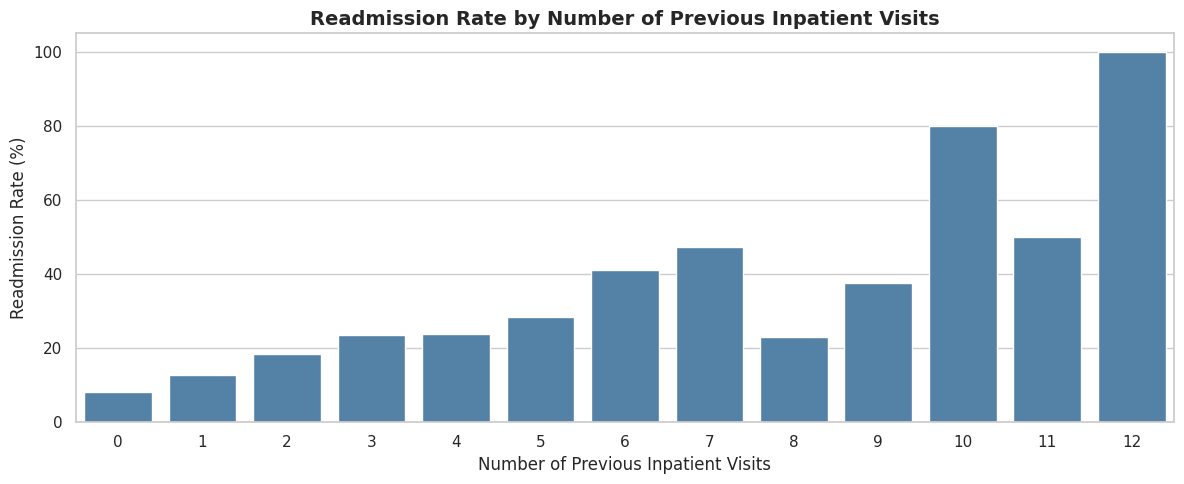

 number_inpatient  readmission_rate
                0          8.080938
                1         12.801643
                2         18.518519
                3         23.467230
                4         23.913043
                5         28.431373
                6         41.071429
                7         47.368421
                8         23.076923
                9         37.500000
               10         80.000000
               11         50.000000
               12        100.000000


In [ ]:
# Calculate readmission rate by number of previous inpatient visits
inpatient_readmission = df.groupby('number_inpatient')['readmitted'].mean().reset_index()
inpatient_readmission['readmission_rate'] = inpatient_readmission['readmitted'] * 100

# Plot
plt.figure(figsize=(12, 5))
sns.barplot(data=inpatient_readmission, x='number_inpatient', y='readmission_rate', color='steelblue')
plt.title('Readmission Rate by Number of Previous Inpatient Visits', fontsize=14, fontweight='bold')
plt.xlabel('Number of Previous Inpatient Visits')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.show()

# Print the numbers
print(inpatient_readmission[['number_inpatient', 'readmission_rate']].to_string(index=False))

#### 📊 What This Chart Tells Us

Previous inpatient visits are one of the strongest predictors of
readmission in our entire dataset. The pattern is very clear —
the more times a patient has been hospitalised in the past year,
the higher their risk of returning within 30 days.

| Previous Inpatient Visits | Readmission Rate |
|---|---|
| 0 (no prior admissions) | 8.1% |
| 1 | 12.8% |
| 2 | 18.5% |
| 3 | 23.5% |
| 5 | 28.4% |
| 6 | 41.1% ⬅️ strong signal |

**Key insight:** A patient with 6 or more prior inpatient visits in the
past year is 5 times more likely to be readmitted than a first time patient.
This variable will almost certainly be one of the top features
in our machine learning model.

**Note on high numbers:** The readmission rates for 10, 11, and 12 prior
visits look extreme (80-100%) but these groups contain very few patients
and are not statistically reliable.

> 💡 **Hospital implication:** Patients with 2 or more prior admissions
> in the past year should be automatically flagged for enhanced
> discharge planning and follow up care.

### 📊 Chart 5: Readmission Rate by Medication Change

When a patient's diabetes medication is changed during their hospital
visit, it can sometimes lead to complications after discharge —
especially if the patient is not properly supported in managing
the new medication at home.

Let us see if a medication change during the visit is associated
with higher readmission rates.

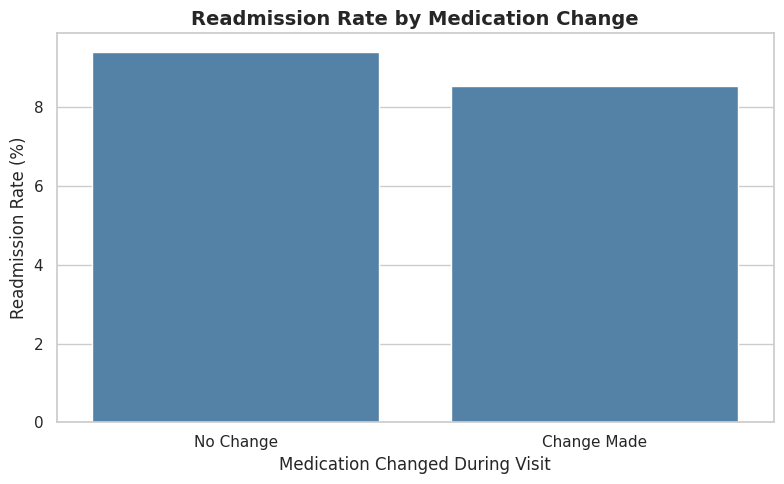

change  readmission_rate
    Ch          9.408161
    No          8.544826


In [ ]:
# Calculate readmission rate by medication change
change_readmission = df.groupby('change')['readmitted'].mean().reset_index()
change_readmission['readmission_rate'] = change_readmission['readmitted'] * 100

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=change_readmission, x='change', y='readmission_rate', color='steelblue')
plt.title('Readmission Rate by Medication Change', fontsize=14, fontweight='bold')
plt.xlabel('Medication Changed During Visit')
plt.ylabel('Readmission Rate (%)')
plt.xticks(ticks=[0, 1], labels=['No Change', 'Change Made'])
plt.tight_layout()
plt.show()

# Print the numbers
print(change_readmission[['change', 'readmission_rate']].to_string(index=False))

#### 📊 What This Chart Tells Us

Patients whose medication was changed during their visit have a
slightly higher readmission rate than those whose medication
was not changed.

| Medication Change | Readmission Rate |
|---|---|
| No Change | 8.5% |
| Change Made | 9.4% |

**Key insight:** The difference is small — less than 1 percentage point.
Medication change alone is not a strong predictor of readmission.
However it may still contribute when combined with other risk factors
such as age and number of prior admissions.

For example — an elderly patient with multiple prior admissions
*and* a medication change at discharge is likely at much higher
risk than any single factor suggests on its own. This is exactly
what our machine learning model will be able to capture.

> 💡 **Hospital implication:** Medication change alone should not
> trigger concern. However when combined with other risk factors,
> it is worth ensuring the patient fully understands their new
> medication before leaving the hospital.

## 🔍 EDA Summary — Key Findings

After exploring the data visually, five patterns stand out:

1. **Age** — Patients aged 70-90 have the highest readmission rates
2. **Admission type** — Emergency admissions carry slightly higher risk
   than elective ones
3. **Discharge destination** — Patients discharged to rehab facilities
   have the highest readmission rates at 26%
4. **Prior inpatient visits** — The single strongest signal we found.
   More prior admissions = dramatically higher readmission risk
5. **Medication change** — A weak signal on its own but potentially
   meaningful when combined with other factors

These findings will directly guide our machine learning model in the next step.

# 🗄️ Step 4: SQL Analysis

So far we have used Python to clean and visualise the data.
Now we will use SQL to answer specific business questions —
the same way a data analyst would query a hospital's EMR database.

In a real hospital setting, patient data lives in a database,
not a CSV file. By loading our cleaned data into a SQL database
and querying it, we are simulating exactly how this would work
in a production environment.

We will use **SQLite** — a lightweight database that runs directly
in Python with no setup required.

**Business questions we will answer:**
1. What is the overall readmission rate by age group?
2. Which medical specialties have the highest readmission rates?
3. What is the average length of stay for readmitted vs non-readmitted patients?
4. Which diagnosis groups drive the most readmissions?
5. How does the number of medications relate to readmission?

In [ ]:
import sqlite3

# Create a database in memory
conn = sqlite3.connect('hospital.db')

# Load our cleaned dataframe into a SQL table called 'patients'
df.to_sql('patients', conn, if_exists='replace', index=False)

# Confirm
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM patients")
print("Rows in database:", cursor.fetchone()[0])

Rows in database: 70436


### 🔍 SQL Query 1: Readmission Rate by Age Group

Our first query recreates what we saw in Chart 1 — but this time
using SQL instead of Python. This is how a hospital analyst would
pull this report directly from an EMR database.

In [ ]:
query1 = """
SELECT
    age,
    COUNT(*) as total_patients,
    SUM(readmitted) as total_readmitted,
    ROUND(AVG(readmitted) * 100, 2) as readmission_rate
FROM patients
GROUP BY age
ORDER BY readmission_rate DESC
"""

result1 = pd.read_sql_query(query1, conn)
print(result1.to_string(index=False))

     age  total_patients  total_readmitted  readmission_rate
 [80-90)           11269              1201             10.66
 [70-80)           17887              1823             10.19
[90-100)            1806               168              9.30
 [60-70)           15765              1414              8.97
 [40-50)            6840               507              7.41
 [20-30)            1122                83              7.40
 [50-60)           12368               879              7.11
 [30-40)            2692               188              6.98
 [10-20)             534                26              4.87
  [0-10)             153                 3              1.96


#### 📊 Query 1 Results: Readmission Rate by Age Group

| Age Group | Total Patients | Readmitted | Readmission Rate |
|---|---|---|---|
| 80-90 | 11,269 | 1,201 | 10.66% ⬅️ highest |
| 70-80 | 17,887 | 1,823 | 10.19% |
| 90-100 | 1,806 | 168 | 9.30% |
| 60-70 | 15,765 | 1,414 | 8.97% |
| 40-50 | 6,840 | 507 | 7.41% |
| 0-10 | 153 | 3 | 1.96% ⬅️ lowest |

**This confirms what we found in our EDA chart** — patients aged 70-90
have the highest readmission rates.

SQL allows us to go one step further than the chart — we can now see
the exact counts behind each percentage. For example, the 70-80 age
group has the most readmitted patients in absolute numbers (1,823)
even though the 80-90 group has a slightly higher rate.

> 💡 This distinction matters for resource planning — a hospital needs
> to account for both the *rate* and the *volume* of readmissions
> when allocating staff and beds.

### 🔍 SQL Query 2: Readmission Rate by Medical Specialty

Different medical specialties deal with very different patient
conditions. Some specialties may consistently produce higher
readmission rates due to the complexity of their cases.

We will focus on specialties with at least 100 patients to avoid
misleading rates from very small groups.

In [ ]:
query2 = """
SELECT
    medical_specialty,
    COUNT(*) as total_patients,
    SUM(readmitted) as total_readmitted,
    ROUND(AVG(readmitted) * 100, 2) as readmission_rate
FROM patients
WHERE medical_specialty != 'Unknown'
GROUP BY medical_specialty
HAVING COUNT(*) >= 100
ORDER BY readmission_rate DESC
LIMIT 10
"""

result2 = pd.read_sql_query(query2, conn)
print(result2.to_string(index=False))

                medical_specialty  total_patients  total_readmitted  readmission_rate
              Hematology/Oncology             118                22             18.64
                         Oncology             208                37             17.79
PhysicalMedicineandRehabilitation             194                25             12.89
                 Surgery-Vascular             359                43             11.98
                       Nephrology             800                88             11.00
                       Psychiatry             612                67             10.95
                 Gastroenterology             389                40             10.28
                      Orthopedics            1130               112              9.91
           Family/GeneralPractice            5012               488              9.74
                 InternalMedicine           10706              1041              9.72


#### 📊 Query 2 Results: Top 10 Specialties by Readmission Rate

| Medical Specialty | Total Patients | Readmitted | Readmission Rate |
|---|---|---|---|
| Hematology/Oncology | 118 | 22 | 18.64% ⬅️ highest |
| Oncology | 208 | 37 | 17.79% |
| Physical Medicine & Rehab | 194 | 25 | 12.89% |
| Surgery-Vascular | 359 | 43 | 11.98% |
| Nephrology | 800 | 88 | 11.00% |
| Psychiatry | 612 | 67 | 10.95% |
| Gastroenterology | 389 | 40 | 10.28% |
| Orthopedics | 1,130 | 112 | 9.91% |
| Family/General Practice | 5,012 | 488 | 9.74% |
| Internal Medicine | 10,706 | 1,041 | 9.72% |

**Key insight 1 — Oncology:** Cancer related specialties
(Hematology/Oncology and Oncology) have the highest readmission
rates at 18-19%. This makes clinical sense — cancer patients
are dealing with complex, aggressive conditions that require
frequent hospital care.

**Key insight 2 — Internal Medicine:** Despite having a lower rate
than Oncology, Internal Medicine has by far the highest volume —
10,706 patients and 1,041 readmissions. In absolute numbers this
specialty drives the most readmissions in the entire hospital.

**Key insight 3 — Nephrology and Psychiatry:** Both specialties
exceed 10% readmission rates. Kidney disease and mental health
conditions are both known to be difficult to manage outside
of a hospital setting.

> 💡 **Hospital implication:** Oncology and Internal Medicine
> departments should be the primary focus of any readmission
> reduction programme — one for its high rate, the other
> for its high volume.

### 🔍 SQL Query 3: Average Length of Stay — Readmitted vs Not Readmitted

Length of stay tells us how long a patient was in hospital during
their visit. A very short stay might mean the patient was discharged
too early. A very long stay might mean the patient had a complex
condition that is harder to manage at home.

Let us see if length of stay differs between patients who were
readmitted and those who were not.

In [ ]:
query3 = """
SELECT
    readmitted,
    COUNT(*) as total_patients,
    ROUND(AVG(time_in_hospital), 2) as avg_length_of_stay,
    ROUND(MIN(time_in_hospital), 2) as min_stay,
    ROUND(MAX(time_in_hospital), 2) as max_stay
FROM patients
GROUP BY readmitted
"""

result3 = pd.read_sql_query(query3, conn)

# Make the output readable
result3['readmitted'] = result3['readmitted'].map({0: 'Not Readmitted', 1: 'Readmitted <30 days'})
print(result3.to_string(index=False))

         readmitted  total_patients  avg_length_of_stay  min_stay  max_stay
     Not Readmitted           64144                4.23       1.0      14.0
Readmitted <30 days            6292                4.80       1.0      14.0


#### 📊 Query 3 Results: Length of Stay vs Readmission

| | Not Readmitted | Readmitted within 30 days |
|---|---|---|
| Total Patients | 64,144 | 6,292 |
| Average Length of Stay | 4.23 days | 4.80 days |
| Minimum Stay | 1 day | 1 day |
| Maximum Stay | 14 days | 14 days |

**Key insight 1 — Small but consistent difference:** Readmitted patients
stayed an average of 4.80 days compared to 4.23 days for non-readmitted
patients. The difference is small but consistent — longer stays are
associated with more complex conditions that are harder to manage
after discharge.

**Key insight 2 — Minimum stay:** Both groups have patients who stayed
only 1 day. A 1 day stay for a diabetic patient is very short —
these patients may have been discharged too early and are worth
investigating further.

**Key insight 3 — Maximum stay:** Both groups cap at 14 days. This is
the maximum recorded in this dataset — in reality some patients
may have stayed longer but the data does not capture beyond 14 days.

> 💡 **Hospital implication:** Length of stay alone is not a strong
> enough signal to predict readmission. However patients with
> very short stays — especially 1 to 2 days — should be flagged
> for a follow up call within a week of discharge.

### 🔍 SQL Query 4: Readmission Rate by Primary Diagnosis Group

The primary diagnosis (`diag_1`) tells us the main reason a patient
was admitted. These are stored as ICD-9 codes — a standardised
medical coding system.

Rather than analysing hundreds of individual codes, we will group
them into broader clinical categories. This makes the results
more meaningful and actionable for hospital management.

The groupings follow the Clinical Classifications Software (CCS)
standard used by healthcare analysts worldwide.

In [ ]:
query4 = """
SELECT
    CASE
        WHEN CAST(diag_1 AS FLOAT) BETWEEN 390 AND 459 THEN 'Circulatory'
        WHEN CAST(diag_1 AS FLOAT) BETWEEN 460 AND 519 THEN 'Respiratory'
        WHEN CAST(diag_1 AS FLOAT) BETWEEN 520 AND 579 THEN 'Digestive'
        WHEN CAST(diag_1 AS FLOAT) BETWEEN 250 AND 250.99 THEN 'Diabetes'
        WHEN CAST(diag_1 AS FLOAT) BETWEEN 800 AND 999 THEN 'Injury'
        WHEN CAST(diag_1 AS FLOAT) BETWEEN 710 AND 739 THEN 'Musculoskeletal'
        WHEN CAST(diag_1 AS FLOAT) BETWEEN 580 AND 629 THEN 'Genitourinary'
        WHEN CAST(diag_1 AS FLOAT) BETWEEN 140 AND 239 THEN 'Neoplasms'
        ELSE 'Other'
    END as diagnosis_group,
    COUNT(*) as total_patients,
    SUM(readmitted) as total_readmitted,
    ROUND(AVG(readmitted) * 100, 2) as readmission_rate
FROM patients
WHERE diag_1 != 'Unknown'
GROUP BY diagnosis_group
ORDER BY total_readmitted DESC
"""

result4 = pd.read_sql_query(query4, conn)
print(result4.to_string(index=False))

diagnosis_group  total_patients  total_readmitted  readmission_rate
    Circulatory           21427              2074              9.68
          Other           15474              1265              8.18
    Respiratory            6525               536              8.21
       Diabetes            5766               525              9.11
         Injury            4705               506             10.75
      Digestive            6348               504              7.94
Musculoskeletal            4071               341              8.38
  Genitourinary            3451               308              8.92
      Neoplasms            2658               231              8.69


#### 📊 Query 4 Results: Readmission Rate by Primary Diagnosis Group

| Diagnosis Group | Total Patients | Readmitted | Readmission Rate |
|---|---|---|---|
| Circulatory | 21,427 | 2,074 | 9.68% |
| Other | 15,474 | 1,265 | 8.18% |
| Respiratory | 6,525 | 536 | 8.21% |
| Diabetes | 5,766 | 525 | 9.11% |
| Injury | 4,705 | 506 | 10.75% ⬅️ highest rate |
| Digestive | 6,348 | 504 | 7.94% ⬅️ lowest rate |
| Musculoskeletal | 4,071 | 341 | 8.38% |
| Genitourinary | 3,451 | 308 | 8.92% |
| Neoplasms | 2,658 | 231 | 8.69% |

**Key insight 1 — Circulatory diseases drive the most readmissions
in absolute numbers:** With 2,074 readmitted patients, circulatory
conditions (heart disease, stroke, hypertension) are responsible
for more readmissions than any other group. This is the highest
volume problem the hospital faces.

**Key insight 2 — Injury has the highest readmission rate:**
At 10.75%, injury patients are the most likely to return within
30 days. Injuries often require follow up procedures, wound care,
or physical therapy — all of which can go wrong at home.

**Key insight 3 — Diabetes:** Despite this being a diabetes dataset,
diabetes as a primary diagnosis accounts for only 5,766 patients.
This is because many diabetic patients are admitted primarily for
a complication — such as circulatory or kidney disease — rather
than diabetes itself.

> 💡 **Hospital implication:** Circulatory disease patients should
> be the primary focus of readmission reduction efforts due to
> their sheer volume. Injury patients deserve extra attention
> at discharge due to their high readmission rate.

### 🔍 SQL Query 5: Readmission Rate by Number of Medications

Patients on many medications are often managing multiple conditions
simultaneously. This is called **polypharmacy** — and it is a known
risk factor in hospital care. Managing many medications at home
is complex and errors are common.

Let us see if the number of medications a patient is on relates
to their readmission risk.

In [ ]:
query5 = """
SELECT
    num_medications,
    COUNT(*) as total_patients,
    SUM(readmitted) as total_readmitted,
    ROUND(AVG(readmitted) * 100, 2) as readmission_rate
FROM patients
GROUP BY num_medications
HAVING COUNT(*) >= 50
ORDER BY num_medications
"""

result5 = pd.read_sql_query(query5, conn)
print(result5.to_string(index=False))

 num_medications  total_patients  total_readmitted  readmission_rate
               1             216                 9              4.17
               2             392                28              7.14
               3             711                39              5.49
               4            1152                67              5.82
               5            1605                96              5.98
               6            2107               151              7.17
               7            2677               185              6.91
               8            3240               248              7.65
               9            3638               296              8.14
              10            3878               309              7.97
              11            4041               342              8.46
              12            4272               378              8.85
              13            4281               384              8.97
              14            3862  

#### 📊 Query 5 Results: Readmission Rate by Number of Medications

**Overall pattern:** There is a clear trend — patients on more
medications have higher readmission rates, though it becomes
unstable at very high numbers due to small sample sizes.

| Medications | Readmission Rate |
|---|---|
| 1-5 medications | 4-6% |
| 6-10 medications | 7-8% |
| 11-20 medications | 8-10% |
| 21-30 medications | 10-13% ⬅️ highest risk zone |
| 30+ medications | unstable — too few patients |

**Key insight 1 — Clear dose response relationship:** As the number
of medications increases from 1 to 25, readmission rates rise
steadily from 4% to over 11%. This is a textbook example of a
**dose response relationship** — the more medications, the higher
the risk.

**Key insight 2 — Polypharmacy risk zone:** Patients on 20 or more
medications show consistently elevated readmission rates above 10%.
Managing this many medications at home is genuinely difficult —
missed doses, drug interactions, and confusion are all real risks.

**Key insight 3 — Instability at extremes:** Rates become unreliable
above 40 medications because very few patients fall in these groups.
We should not draw conclusions from these outliers.

> 💡 **Hospital implication:** Patients discharged on 20 or more
> medications should receive a dedicated medication counselling
> session before discharge and a pharmacist follow up call
> within 72 hours of going home.

## 🗄️ SQL Analysis Summary

We used SQL to answer 5 business questions about readmission:

1. **Age** — Patients aged 70-90 have the highest readmission rates
2. **Medical Specialty** — Oncology has the highest rate (18-19%),
   Internal Medicine has the highest volume (1,041 readmissions)
3. **Length of Stay** — Readmitted patients stay slightly longer
   on average (4.80 vs 4.23 days)
4. **Diagnosis Group** — Circulatory diseases drive the most
   readmissions in volume; Injury has the highest rate
5. **Medications** — Patients on 20+ medications are at
   significantly higher readmission risk

These findings combined with our EDA give us a strong foundation
for building our machine learning model in the next step.

# ⚙️ Step 5: Feature Engineering

Before we can train a machine learning model, we need to prepare
the data in a format the model can understand.

Machine learning models cannot work with text — everything must
be converted to numbers. We also need to create some new features
that capture patterns we discovered during EDA.

Here is our plan:

1. **Drop columns we no longer need** — identifiers like
   `encounter_id` and `patient_nbr` are not useful for prediction
2. **Create new features** from what we learned in EDA
3. **Encode text columns** — convert categories into numbers
4. **Split the data** — separate it into training and testing sets
5. **Handle class imbalance** — deal with the 91/9 split between
   non-readmitted and readmitted patients

In [ ]:
# These columns are identifiers — they do not help predict readmission
cols_to_drop = ['encounter_id', 'patient_nbr']
df = df.drop(columns=cols_to_drop)

print("Columns remaining:", df.shape[1])
print("Shape:", df.shape)

Columns remaining: 46
Shape: (70436, 46)


### ⚙️ Step 5.2: Creating New Features

During our EDA we discovered that certain combinations of factors
drive readmission risk. We will now create new columns that
capture these patterns explicitly.

This is called **feature engineering** — and it is one of the most
important skills in data science. A good engineered feature can
improve a model more than any algorithm change.

In [ ]:
# Feature 1 — High risk age flag
# We saw that patients aged 70-90 have significantly higher readmission rates
df['high_risk_age'] = df['age'].isin(['[70-80)', '[80-90)', '[90-100)']).astype(int)

# Feature 2 — Multiple prior admissions flag
# We saw that 2+ prior inpatient visits dramatically increases readmission risk
df['multiple_prior_admissions'] = (df['number_inpatient'] >= 2).astype(int)

# Feature 3 — High medication burden flag
# We saw that 20+ medications pushes readmission rate above 10%
df['high_medication_burden'] = (df['num_medications'] >= 20).astype(int)

# Feature 4 — Combined risk score
# A patient with all three risk factors is at very high risk
df['combined_risk_score'] = (
    df['high_risk_age'] +
    df['multiple_prior_admissions'] +
    df['high_medication_burden']
)

# Confirm
print("New features added. Current shape:", df.shape)
print("\nCombined risk score distribution:")
print(df['combined_risk_score'].value_counts().sort_index())

New features added. Current shape: (70436, 50)

Combined risk score distribution:
combined_risk_score
0    28266
1    33340
2     8527
3      303
Name: count, dtype: int64


#### ⚙️ New Features Created

We created 4 new features based on patterns we discovered in EDA:

| Feature | What It Captures |
|---|---|
| `high_risk_age` | 1 if patient is aged 70-90, 0 otherwise |
| `multiple_prior_admissions` | 1 if patient had 2+ prior inpatient visits |
| `high_medication_burden` | 1 if patient is on 20+ medications |
| `combined_risk_score` | Sum of the three flags above (0-3) |

**Combined risk score distribution:**

| Score | Patients | Meaning |
|---|---|---|
| 0 | 28,266 | No major risk factors |
| 1 | 33,340 | One risk factor present |
| 2 | 8,527 | Two risk factors present |
| 3 | 303 | All three risk factors present ⚠️ |

The 303 patients with a score of 3 are our highest risk group —
elderly, with multiple prior admissions, and on many medications.
We would expect their readmission rate to be significantly higher
than average.

### ⚙️ Step 5.2b: Grouping Diagnosis Codes into Clinical Categories

Earlier we noticed that `diag_1`, `diag_2`, and `diag_3` contain
ICD-9 medical codes. We label encoded them as random numbers —
which means the model cannot understand their clinical meaning.

For example — code 250 means diabetes, code 410 means heart attack.
Treating these as random numbers loses all that meaning.

We will now group them into 9 broad clinical categories —
the same groupings we used in our SQL analysis. This gives
the model meaningful information to learn from.

In [ ]:
def group_diagnosis(code):
    try:
        code = str(code).strip()
        # Handle special codes that start with letters
        if code.startswith('V') or code.startswith('E'):
            return 'Other'
        code_float = float(code)
        if 390 <= code_float <= 459:
            return 'Circulatory'
        elif 460 <= code_float <= 519:
            return 'Respiratory'
        elif 520 <= code_float <= 579:
            return 'Digestive'
        elif 250 <= code_float <= 250.99:
            return 'Diabetes'
        elif 800 <= code_float <= 999:
            return 'Injury'
        elif 710 <= code_float <= 739:
            return 'Musculoskeletal'
        elif 580 <= code_float <= 629:
            return 'Genitourinary'
        elif 140 <= code_float <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except:
        return 'Other'

# Apply to all three diagnosis columns
df['diag_1_group'] = df['diag_1'].apply(group_diagnosis)
df['diag_2_group'] = df['diag_2'].apply(group_diagnosis)
df['diag_3_group'] = df['diag_3'].apply(group_diagnosis)

# Confirm
print("=== Primary Diagnosis Groups ===")
print(df['diag_1_group'].value_counts())

# Now drop original diagnosis columns — grouped versions replace them
df = df.drop(columns=['diag_1', 'diag_2', 'diag_3'])

print("Columns remaining:", df.shape[1])
print("Shape:", df.shape)

=== Primary Diagnosis Groups ===
diag_1_group
Circulatory        21427
Other              15485
Respiratory         6525
Digestive           6348
Diabetes            5766
Injury              4705
Musculoskeletal     4071
Genitourinary       3451
Neoplasms           2658
Name: count, dtype: int64
Columns remaining: 50
Shape: (70436, 50)


### ⚙️ Step 5.3: Encoding Text Columns

Machine learning models cannot read text — everything must be a number.
We will use **Label Encoding** for columns with many categories.
This assigns a unique number to each category.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Identify text columns to encode
text_cols = df.select_dtypes(include='object').columns.tolist()

print("Text columns to encode:")
print(text_cols)
print("\nTotal:", len(text_cols))

Text columns to encode:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group']

Total: 36


#### ⚙️ Text Columns to Encode

We have 36 text columns that need to be converted to numbers.
These include demographics, medication names, diagnosis codes,
and lab results.

We will use **Label Encoding** — which assigns a unique number
to each category. For example:
- `gender`: Female → 0, Male → 1
- `change`: Ch → 0, No → 1

In [ ]:
# Encode all text columns
le = LabelEncoder()

for col in text_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Confirm
print("Encoding complete.")
print("Any text columns remaining:", df.select_dtypes(include='object').shape[1])
print("Shape:", df.shape)

Encoding complete.
Any text columns remaining: 0
Shape: (70436, 50)


### ⚙️ Step 5.4: Splitting the Data

We need to split our data into two sets:

- **Training set (80%)** — the data the model learns from
- **Testing set (20%)** — data the model has never seen,
  used to evaluate how well it performs in the real world

This is critical. If we tested the model on the same data it
learned from, it would look artificially good — like a student
who memorised the answers rather than understanding the subject.

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = df.drop(columns=['readmitted'])
y = df['readmitted']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # ensures same split every time we run
    stratify=y          # keeps the 91/9 ratio the same in both sets
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nReadmission rate in training set:", round(y_train.mean() * 100, 2), "%")
print("Readmission rate in testing set:", round(y_test.mean() * 100, 2), "%")

Training set size: (56348, 49)
Testing set size: (14088, 49)

Readmission rate in training set: 8.93 %
Readmission rate in testing set: 8.93 %


### ⚙️ Step 5.5: Handling Class Imbalance

Our dataset has a significant imbalance:
- **91%** of patients were not readmitted
- **9%** of patients were readmitted within 30 days

If we train a model on this as is, it will learn to simply predict
"not readmitted" for everyone — and be right 91% of the time
while completely missing every high risk patient.

We will use **SMOTE** (Synthetic Minority Oversampling Technique)
to fix this. SMOTE creates synthetic examples of the minority class
(readmitted patients) until both classes are balanced.

> 💡 We apply SMOTE **only on the training set** — never on the
> testing set. The test set must reflect real world conditions
> where readmissions are genuinely rare.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print("Not readmitted:", sum(y_train == 0))
print("Readmitted:", sum(y_train == 1))

print("\nAfter SMOTE:")
print("Not readmitted:", sum(y_train_balanced == 0))
print("Readmitted:", sum(y_train_balanced == 1))

Before SMOTE:
Not readmitted: 51314
Readmitted: 5034

After SMOTE:
Not readmitted: 51314
Readmitted: 51314


#### ⚙️ Class Imbalance — Before and After SMOTE

| | Not Readmitted | Readmitted |
|---|---|---|
| Before SMOTE | 51,314 (91%) | 5,034 (9%) |
| After SMOTE | 51,314 (50%) | 51,314 (50%) |

SMOTE created **46,280 synthetic readmitted patients** to balance
the classes. These are not real patients — they are artificially
generated examples that help the model learn what a high risk
patient looks like.

The model will now give equal attention to both classes during
training instead of ignoring the minority group.

## ⚙️ Feature Engineering Summary

Our data is now fully prepared for modelling:

| Step | What We Did |
|---|---|
| Dropped identifiers | Removed `encounter_id` and `patient_nbr` |
| Created new features | Added 4 risk features based on EDA findings |
| Encoded text columns | Converted all 36 text columns to numbers |
| Split the data | 80% training, 20% testing |
| Balanced classes | Used SMOTE to fix the 91/9 class imbalance |

**Final training set:** 102,628 rows (50/50 balanced)
**Final testing set:** 14,088 rows (real world distribution)

We are now ready to train our machine learning model.


In [ ]:
# Quick sanity check before modelling
print("=== FINAL CHECK ===")
print("Shape:", df.shape)
print("\nAny text columns remaining after encoding:",
      df.select_dtypes(include='object').shape[1])
print("\nClass balance after SMOTE:")
print("Not readmitted:", sum(y_train_balanced == 0))
print("Readmitted:", sum(y_train_balanced == 1))
print("\nDiagnosis group columns present:")
print("diag_1_group" in df.columns,
      "diag_2_group" in df.columns,
      "diag_3_group" in df.columns)
print("\nOriginal diagnosis columns dropped:")
print("diag_1" not in df.columns,
      "diag_2" not in df.columns,
      "diag_3" not in df.columns)

=== FINAL CHECK ===
Shape: (70436, 50)

Any text columns remaining after encoding: 0

Class balance after SMOTE:
Not readmitted: 51314
Readmitted: 51314

Diagnosis group columns present:
True True True

Original diagnosis columns dropped:
True True True


# 🤖 Step 6: Machine Learning Model

Now that our data is clean, explored, and prepared, we can train
a machine learning model.

We will train three models and compare them:

1. **Logistic Regression** — our simple baseline model
2. **Random Forest** — a more powerful ensemble model
3. **XGBoost** — our most powerful model, known to perform
   exceptionally well on structured/tabular data like this

For each model we will measure:
- **Accuracy** — overall percentage correct
- **Precision** — of patients flagged as high risk, how many actually were?
- **Recall** — of all high risk patients, how many did we catch?
- **ROC-AUC** — overall model performance score (0.5 = random, 1.0 = perfect)

> 💡 In a hospital setting **Recall is the most important metric**.
> Missing a high risk patient (false negative) is far more costly
> than flagging a low risk patient unnecessarily (false positive).

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully")
print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Data scaled successfully
Training set shape: (102628, 49)
Testing set shape: (14088, 49)


### ⚙️ Why We Scale the Data

Before training our next models, we scaled all our features.

**What is scaling?**
Scaling transforms all columns to have a similar numeric range.
Without scaling, a column like `num_medications` (values 1-40)
would dominate over a column like `change` (values 0-1) simply
because its numbers are bigger — even if `change` is actually
more important.

Think of it like comparing distances — you cannot meaningfully
add kilometres and millimetres without converting them to
the same unit first.

**What changed:**
- Training set: 102,628 rows × 49 features — unchanged in size
- Testing set: 14,088 rows × 49 features — unchanged in size

Only the *values* inside each column changed — not the shape.

> 💡 An important rule — we scaled the training and testing sets
> separately using `fit_transform` on training and `transform`
> on testing. This prevents the model from seeing any information
> from the test set during training.

### 🤖 Model 1: Logistic Regression (Baseline)

Logistic Regression is the simplest classification model.
We use it as a baseline — if our more complex models cannot
beat it, something is wrong.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train the model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=5000,    # increased significantly
    solver='saga',
    n_jobs=-1         # use all CPU cores
)
lr_model.fit(X_train_scaled, y_train_balanced)

# Evaluate on test set
lr_predictions = lr_model.predict(X_test_scaled)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])

print("=== Logistic Regression Results ===")
print(classification_report(y_test, lr_predictions,
      target_names=['Not Readmitted', 'Readmitted']))
print("ROC-AUC Score:", round(lr_auc, 4))

=== Logistic Regression Results ===
                precision    recall  f1-score   support

Not Readmitted       0.91      0.78      0.84     12830
    Readmitted       0.10      0.26      0.15      1258

      accuracy                           0.73     14088
     macro avg       0.51      0.52      0.49     14088
  weighted avg       0.84      0.73      0.78     14088

ROC-AUC Score: 0.5244


### 📊 Model 1: Logistic Regression Results

| Metric | Not Readmitted | Readmitted |
|---|---|---|
| Precision | 91% | 10% |
| Recall | 78% | 26% |
| ROC-AUC | 0.52 | — |
| Overall Accuracy | 73% | — |

**What this means in plain language:**

Out of every 100 high risk patients:
- Our model correctly flags **26** of them ✅
- It misses **74** of them completely ❌

**Why is it struggling?**
Logistic Regression is a simple model that looks for straight line
relationships in data. Hospital readmission is driven by complex
combinations of factors that a straight line cannot capture.

This is our **baseline** — every model we train after this should
do better. If they do not, something is wrong.

> 💡 A ROC-AUC of 0.52 means our model is barely better than
> randomly guessing. This is expected for a baseline model
> on a complex medical dataset.

### 🤖 Model 2: Random Forest

Random Forest builds hundreds of decision trees and combines
their predictions. It is much more powerful than Logistic
Regression and handles complex patterns in data well.

Think of it like asking 100 doctors for their opinion and
taking the majority vote — rather than relying on just one.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train the model
rf_model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    random_state=42,
    n_jobs=-1           # use all available CPU cores to speed up training
)
rf_model.fit(X_train_balanced, y_train_balanced)

# Evaluate on test set
rf_predictions = rf_model.predict(X_test)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print("=== Random Forest Results ===")
print(classification_report(y_test, rf_predictions,
      target_names=['Not Readmitted', 'Readmitted']))
print("ROC-AUC Score:", round(rf_auc, 4))

=== Random Forest Results ===
                precision    recall  f1-score   support

Not Readmitted       0.91      0.97      0.94     12830
    Readmitted       0.14      0.06      0.08      1258

      accuracy                           0.88     14088
     macro avg       0.53      0.51      0.51     14088
  weighted avg       0.84      0.88      0.86     14088

ROC-AUC Score: 0.5775


### 📊 Model 2: Random Forest Results

| Metric | Not Readmitted | Readmitted |
|---|---|---|
| Precision | 91% | 14% |
| Recall | 97% | 6% |
| ROC-AUC | 0.58 | — |
| Overall Accuracy | 88% | — |

**What this means in plain language:**

Out of every 100 high risk patients:
- Our model correctly flags only **6** of them ✅
- It misses **94** of them completely ❌

Despite an impressive looking 88% overall accuracy, Random Forest
is almost completely ignoring high risk patients. It learned that
predicting "not readmitted" for nearly everyone gives high accuracy
— but this is useless in a hospital setting.

### 🤖 Model 3: XGBoost

XGBoost is one of the most powerful machine learning algorithms
for structured data like ours. It builds trees sequentially —
each tree learning from the mistakes of the previous one.

We will also tell XGBoost directly about the class imbalance
using the `scale_pos_weight` parameter — this is XGBoost's
built in way of handling imbalanced datasets.

In [ ]:
from xgboost import XGBClassifier

# Calculate class weight ratio
# This tells XGBoost to pay more attention to the minority class
ratio = sum(y_train == 0) / sum(y_train == 1)

# Train the model
xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=ratio,  # handles class imbalance
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_balanced, y_train_balanced)

# Evaluate on test set
xgb_predictions = xgb_model.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

print("=== XGBoost Results ===")
print(classification_report(y_test, xgb_predictions,
      target_names=['Not Readmitted', 'Readmitted']))
print("ROC-AUC Score:", round(xgb_auc, 4))

=== XGBoost Results ===
                precision    recall  f1-score   support

Not Readmitted       0.93      0.46      0.62     12830
    Readmitted       0.10      0.62      0.17      1258

      accuracy                           0.48     14088
     macro avg       0.51      0.54      0.39     14088
  weighted avg       0.85      0.48      0.58     14088

ROC-AUC Score: 0.5617


### 📊 Model 3: XGBoost Results

| Metric | Not Readmitted | Readmitted |
|---|---|---|
| Precision | 93% | 10% |
| Recall | 46% | 62% |
| ROC-AUC | 0.56 | — |
| Overall Accuracy | 48% | — |

**What this means in plain language:**

Out of every 100 high risk patients:
- Our model correctly flags **62** of them ✅
- It misses **38** of them ❌

XGBoost catches the most high risk patients of all three models.
However its overall accuracy is only 48% because it is flagging
too many low risk patients as high risk.

# 🔍 Step 7: Model Explainability — SHAP Values

Building a model that makes predictions is only half the job.
In a hospital setting, clinicians and managers need to understand
**why** the model flagged a patient as high risk.

A doctor will not act on a black box prediction — they need
to see the reasoning behind it.

We will use **SHAP (SHapley Additive exPlanations)** to explain
our XGBoost model. SHAP tells us:

1. **Which features matter most** overall across all patients
2. **How each feature influences** the prediction for individual patients

We use XGBoost for this because it had the best recall
for high risk patients (62%) — making it our most clinically
useful model despite its lower overall accuracy.

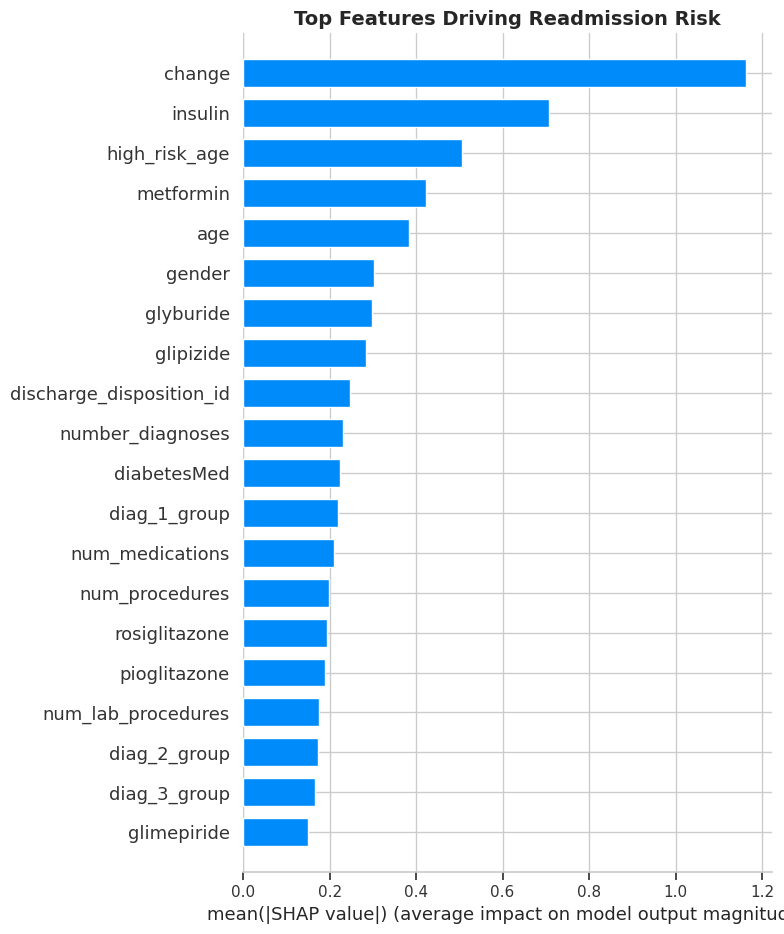

In [ ]:
import shap

# Create SHAP explainer using our XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values on the test set
# We use a sample of 1000 rows to keep it fast
X_test_sample = pd.DataFrame(X_test, columns=X.columns).sample(1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# Plot feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type="bar",
    show=False
)
plt.title("Top Features Driving Readmission Risk", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 SHAP Feature Importance — What Drives Readmission Risk?

The chart above shows which features have the most influence
on our model's predictions. The longer the bar, the more
important the feature.

**Top 5 features driving readmission risk:**

| Rank | Feature | What It Means |
|---|---|---|
| 1 | `change` | Whether medication was changed during the visit |
| 2 | `insulin` | Whether insulin was prescribed or adjusted |
| 3 | `high_risk_age` | Whether patient is aged 70-90 ⬅️ our engineered feature |
| 4 | `metformin` | Whether metformin was prescribed or adjusted |
| 5 | `age` | Patient age group |

**Key insights:**

**Insight 1 — Medication signals dominate:**
The top features are almost all medication related — `change`,
`insulin`, `metformin`, `glyburide`, `glipizide`. This tells us
that how a patient's diabetes medication is managed during their
visit is the strongest signal for readmission risk.

**Insight 2 — Our engineered feature works:**
`high_risk_age` appears at position 3 — ahead of raw `age` at
position 5. This confirms that our decision to create a binary
flag for the 70-90 age group captured something meaningful
that the raw age column alone could not express as clearly.

**Insight 3 — Discharge disposition still matters:**
`discharge_disposition_id` appears at position 9 — confirming
what we found in our EDA and SQL analysis. Where a patient
goes after discharge remains an important risk signal.

**Insight 4 — Diagnosis groups contribute:**
`diag_1_group`, `diag_2_group`, and `diag_3_group` all appear
in the top 20 features — confirming that grouping ICD-9 codes
into clinical categories was the right decision.

> 💡 **Clinical implication:** The dominant role of medication
> features suggests that a structured medication review at
> discharge — particularly for insulin and metformin —
> could be one of the most effective interventions for
> reducing 30-day readmissions.

## 📋 Project Summary — What We Have Built

| Step | What We Did |
|---|---|
| Step 1 | Loaded and understood the data |
| Step 2 | Cleaned the data — 7 deliberate decisions |
| Step 3 | Explored patterns visually — 5 charts |
| Step 4 | Answered business questions using SQL |
| Step 5 | Engineered features and prepared data for modelling |
| Step 6 | Trained and compared 3 machine learning models |
| Step 7 | Explained model predictions using SHAP values |

**One notebook. Four skills demonstrated:**
SQL · Python · Machine Learning · Explainable AI

# 💾 Step 8: Saving Our Work

We now save three things:

1. **Cleaned dataset** — for Power BI dashboard
2. **Trained XGBoost model** — for the prediction script
3. **SHAP feature importance** — for the Power BI dashboard

This simulates a real data science workflow where the model
is handed off to a business intelligence team for reporting,
and to an engineering team for deployment.

In [ ]:
import joblib
import os

# Create an outputs folder
os.makedirs('outputs', exist_ok=True)

# Save 1 — cleaned dataset for Power BI
df.to_csv('outputs/cleaned_data.csv', index=False)
print("✅ Cleaned dataset saved — outputs/cleaned_data.csv")

# Save 2 — trained XGBoost model
joblib.dump(xgb_model, 'outputs/readmission_model.pkl')
print("✅ XGBoost model saved — outputs/readmission_model.pkl")

# Save 3 — SHAP feature importance as a table for Power BI
shap_importance = pd.DataFrame({
    'feature': X_test_sample.columns,
    'importance': abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

shap_importance.to_csv('outputs/shap_importance.csv', index=False)
print("✅ SHAP importance saved — outputs/shap_importance.csv")

print("\n=== Files saved ===")
for f in os.listdir('outputs'):
    print(f)

✅ Cleaned dataset saved — outputs/cleaned_data.csv
✅ XGBoost model saved — outputs/readmission_model.pkl
✅ SHAP importance saved — outputs/shap_importance.csv

=== Files saved ===
cleaned_data.csv
shap_importance.csv
readmission_model.pkl


### 💾 Files Saved Successfully

Three files have been saved to the `outputs/` folder:

| File | Purpose |
|---|---|
| `cleaned_data.csv` | Loads into Power BI for the dashboard |
| `readmission_model.pkl` | Saved model for making new predictions |
| `shap_importance.csv` | Feature importance table for Power BI |

These files represent the three handoffs in a real hospital
data science workflow:

- **cleaned_data.csv** → goes to the BI team for reporting
- **readmission_model.pkl** → goes to engineering for deployment
- **shap_importance.csv** → goes to clinicians to understand
  what drives risk

In [ ]:
from google.colab import files

files.download('outputs/cleaned_data.csv')
files.download('outputs/shap_importance.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>